# 01. Демонстрация градиентного спуска

Визуализация того, как градиентный спуск сходится к минимуму функции `f(x, y) = x² + y²`,
и что происходит при разных значениях learning rate: слишком маленький (медленная сходимость),
оптимальный, и слишком большой (расхождение / осцилляции).


In [1]:
import sys
sys.path.append('../src/part1_from_scratch')

import numpy as np
import matplotlib.pyplot as plt

from gradient_descent import predict_trajectory_2d


## Функция потерь и её градиент

Берём простую выпуклую функцию `f(x, y) = x² + y²` с единственным минимумом в точке `(0, 0)`.
Её градиент: `∇f(x, y) = (2x, 2y)`.


In [2]:
def f(p):
    return p[0] ** 2 + p[1] ** 2

def grad_f(p):
    return np.array([2 * p[0], 2 * p[1]])

start_point = [4.0, 3.0]


## Траектории при разных learning rate


In [3]:
learning_rates = {
    'lr=0.05 (медленно)': 0.05,
    'lr=0.3 (оптимально)': 0.3,
    'lr=1.05 (расходится)': 1.05,
}

trajectories = {
    name: predict_trajectory_2d(grad_f, f, start_point, lr=lr, n_steps=30)
    for name, lr in learning_rates.items()
}

for name, traj in trajectories.items():
    print(f"{name}: старт {traj[0]} -> финиш {traj[-1]}, f(финиш)={f(traj[-1]):.4f}")


lr=0.05 (медленно): старт [4. 3.] -> финиш [0.16956463 0.12717347], f(финиш)=0.0449
lr=0.3 (оптимально): старт [4. 3.] -> финиш [4.61168602e-12 3.45876451e-12], f(финиш)=0.0000
lr=1.05 (расходится): старт [4. 3.] -> финиш [69.79760908 52.34820681], f(финиш)=7612.0410


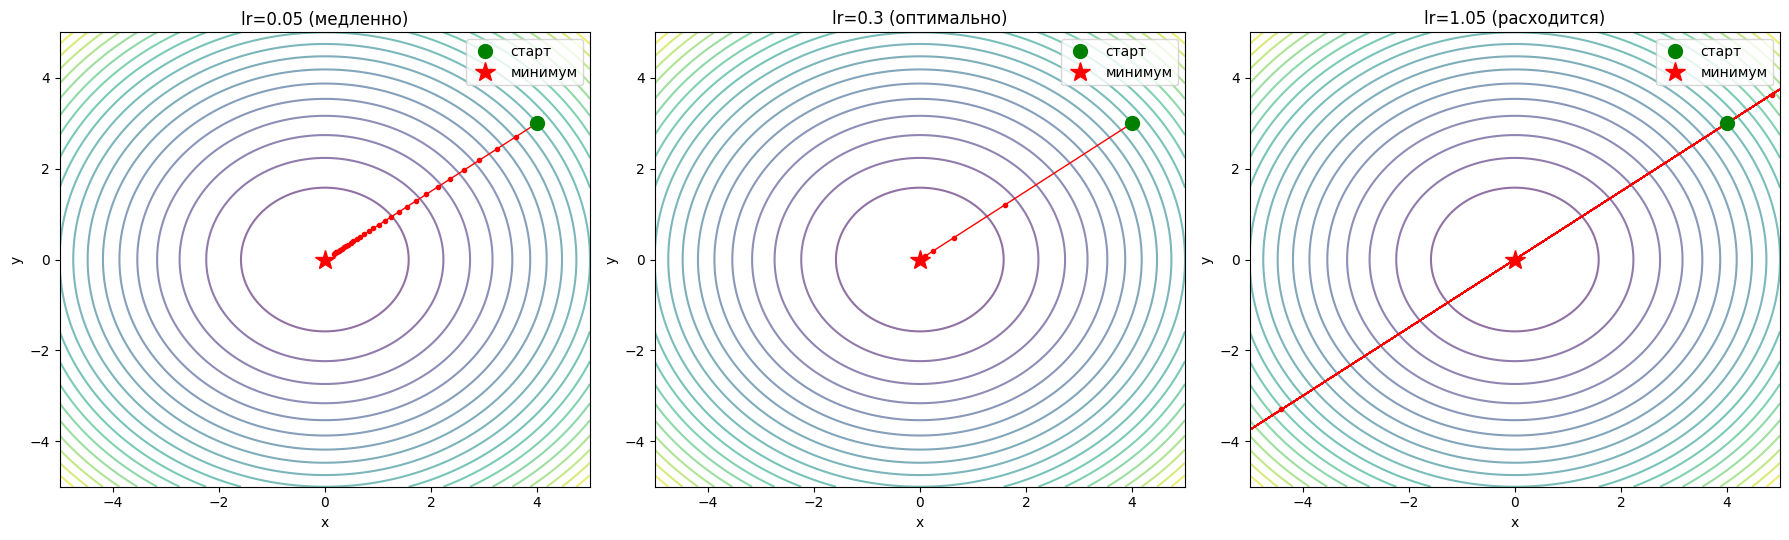

In [4]:
# Контурный график + траектории
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = X ** 2 + Y ** 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, (name, traj) in zip(axes, trajectories.items()):
    ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color='red', markersize=3, linewidth=1)
    ax.plot(traj[0, 0], traj[0, 1], 'go', markersize=10, label='старт')
    ax.plot(0, 0, 'r*', markersize=15, label='минимум')
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)

plt.tight_layout()
plt.savefig('../results/gd_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()


## Вывод

- При слишком маленьком `lr` спуск идёт устойчиво, но требует много шагов.
- При хорошо подобранном `lr` сходимость быстрая и стабильная.
- При слишком большом `lr` шаги перепрыгивают минимум и точка расходится — это именно то,
  что нужно иметь в виду при подборе `lr` для линейной/логистической регрессии дальше.
